# 6-DOF SCARA Robot: Kinematics, Workspace, and Motion Walkthrough

This notebook presents the academic SCARA project as a reproducible technical walkthrough. It follows the analytical model in the final report, with one documented correction: the prismatic coordinate $l_2$ translates along local $+Y$.

Each section follows the same pattern: **theory and purpose → mathematics or logic → relevant code → result → interpretation**. Distances are in millimetres and angles are in degrees unless stated otherwise.

## 1. Project overview and application

### Theory and purpose
The project studies a stationary SCARA-type manipulator intended for pick-and-place sorting of dates between conveyor lines. Its analytical model has four revolute joints and two prismatic joints. Python is used for kinematics, workspace sampling, trajectory analysis, plotting, and an illustrative animation.

### Logic
The notebook uses a small shared module so that the equations shown here, the original scripts, and the numerical checks all execute the same implementation.

### Mathematical foundation
The robot configuration is represented by the generalized-coordinate vector

$$
\mathbf q = [\theta_1,\;l_1,\;l_2,\;\theta_2,\;\theta_3,\;\theta_4]^T.
$$

Each revolute joint contributes a rotation matrix and each prismatic joint contributes a translation. Using homogeneous transformations,

$$
{}^{0}\!T_{6}(\mathbf q)=
T_z(800)R_z(\theta_1)T_z(l_1)T_y(l_2)
T_y(150)R_y(\theta_2)R_z(\theta_3)T_y(150)R_y(\theta_4).
$$

The upper-left $3\times3$ block is the tool orientation ${}^{0}\!R_6$ and the final column is the tool position $\mathbf p=f(\mathbf q)$. User-facing angles are expressed in degrees and converted to radians for trigonometric evaluation; lengths are expressed in millimetres.

Forward kinematics evaluates $f(\mathbf q)$. The supported inverse-position problem selects a wrist posture and solves

$$
f_p(\theta_1,l_1,l_2\mid\theta_2,\theta_3)=\mathbf p_d,
$$

while $\theta_4$ remains free for a position-only task. A Cartesian trajectory is defined by

$$
\mathbf p_c(t)=\mathbf p_0+s(t)(\mathbf p_f-\mathbf p_0),
$$

where $s(t)$ follows a trapezoidal-speed law. The achieved trajectory is recomputed using forward kinematics, and the validation quantity is

$$
e_p(t)=\left\|\mathbf p_c(t)-f(\mathbf q(t))\right\|_2.
$$

The following sections derive these relationships, test the five reference configurations, and then apply them to workspace, trajectory, velocity, and loading analysis.

In [1]:
from pathlib import Path
import sys
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'scara_model.py').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from scara_model import (
    BASE_HEIGHT_MM, JOINT_LIMITS, REFERENCE_CASES, WRIST_OFFSET_MM,
    forward_kinematics, inverse_position, plan_cartesian_trajectory,
    sample_workspace, static_payload_reactions,
)

plt.style.use('seaborn-v0_8-whitegrid')
print('Shared analytical model loaded from:', PROJECT_ROOT / 'scara_model.py')
print('Canonical joint order: [theta1, l1, l2, theta2, theta3, theta4]')

Shared analytical model loaded from: C:\Users\User\Documents\GitHub\scara-6dof-project\scara_model.py
Canonical joint order: [theta1, l1, l2, theta2, theta3, theta4]


### Result and interpretation
The notebook imports reusable numerical functions rather than copying either large original script. This keeps the presentation readable while preserving executable links to the project code.

## 2. Robot structure, joints, units, and assumptions

### Theory and purpose
The canonical generalized-coordinate vector is

$$q=[\theta_1, l_1, l_2, \theta_2, \theta_3, \theta_4].$$

The analytical model is a one-dimensional stick model. It does not attempt collision checking, rigid-body dynamics, actuator sizing, or exact correspondence with the ROS geometry.

### Logic
The declared limits from the report are summarized below.

### Robot architecture
This original project schematic shows the physical idea behind the model: a rotating base, vertical and horizontal prismatic motion, a three-rotation wrist, and a gripper.

![SCARA robot structure and joint variables from the project report](assets/report_robot_structure.png)

The six actuated coordinates are ordered as $[\theta_1,l_1,l_2,\theta_2,\theta_3,\theta_4]$. The figure supplies physical context; the equations and numerical checks below define the corrected analytical convention.

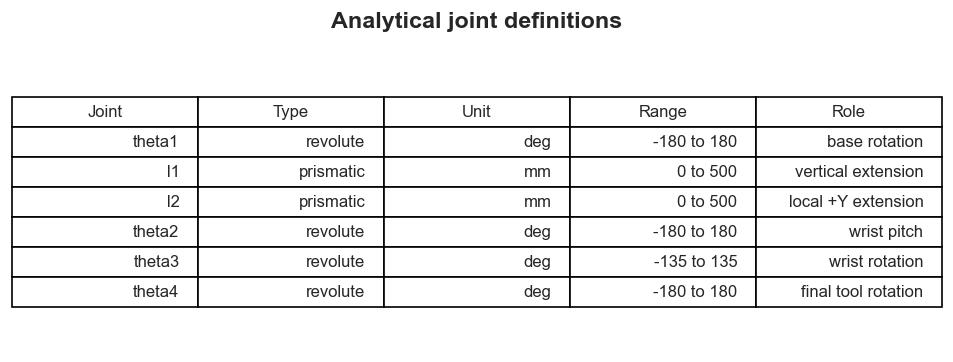

In [2]:
joint_rows = [
    ['theta1', 'revolute', 'deg', '-180 to 180', 'base rotation'],
    ['l1', 'prismatic', 'mm', '0 to 500', 'vertical extension'],
    ['l2', 'prismatic', 'mm', '0 to 500', 'local +Y extension'],
    ['theta2', 'revolute', 'deg', '-180 to 180', 'wrist pitch'],
    ['theta3', 'revolute', 'deg', '-135 to 135', 'wrist rotation'],
    ['theta4', 'revolute', 'deg', '-180 to 180', 'final tool rotation'],
]
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.axis('off')
table = ax.table(cellText=joint_rows, colLabels=['Joint', 'Type', 'Unit', 'Range', 'Role'], loc='center')
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1, 1.5)
ax.set_title('Analytical joint definitions', fontsize=14, fontweight='bold', pad=16)
plt.show()

### Result and interpretation
Two linear coordinates provide vertical and horizontal reach, while the four rotations control the base and wrist. The external Python API consistently uses degrees and millimetres.

## 3. Coordinate convention

### Theory and purpose
A consistent coordinate convention is essential because earlier test data mixed the X and Y axes. The world frame is right-handed, $+Z$ is vertical, and the zero-angle arm points along $+Y$. Positive $\theta_1$ rotates about $+Z$.

### Mathematical logic
The corrected prismatic transform is $^2T_3=\mathrm{Trans}_Y(l_2)$, not a Z translation. At zero wrist angles the horizontal direction is $[-\sin\theta_1,\cos\theta_1]$.

### Coordinate-frame diagram
The original project diagram below identifies the successive local frames attached to the base, translating links, and wrist joints.

![Robot coordinate systems from the project report](assets/report_coordinate_systems.png)

The corrected analytical convention used throughout this notebook defines $l_2$ as translation along local $+Y$. That explicit statement resolves the directional ambiguity found in parts of the original written material.

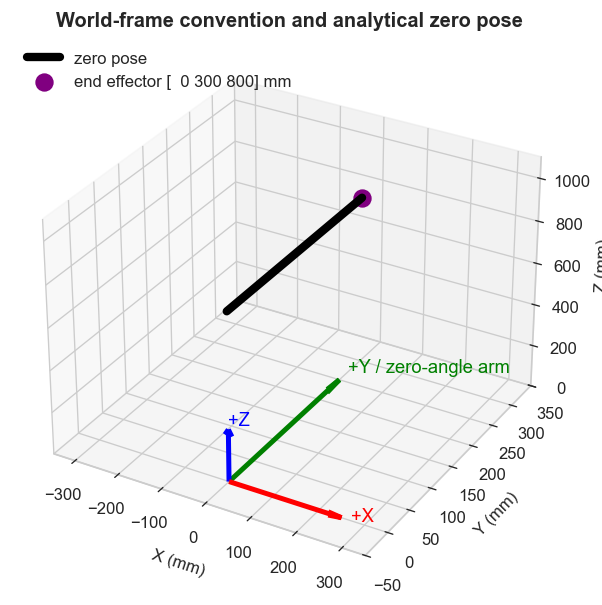

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
origin = np.zeros(3)
for vector, color, label in [(np.array([250,0,0]), 'r', '+X'), (np.array([0,250,0]), 'g', '+Y / zero-angle arm'), (np.array([0,0,250]), 'b', '+Z')]:
    ax.quiver(*origin, *vector, color=color, linewidth=3, arrow_length_ratio=0.12)
    ax.text(*(vector * 1.08), label, color=color, fontsize=11)
zero_pose = forward_kinematics(0, 0, 0, 0, 0, 0)
ax.plot([0, zero_pose[0]], [0, zero_pose[1]], [800, zero_pose[2]], 'k-', linewidth=5, label='zero pose')
ax.scatter(*zero_pose, s=100, c='purple', label=f'end effector {zero_pose.astype(int)} mm')
ax.set(xlim=(-350,350), ylim=(-50,350), zlim=(0,1100), xlabel='X (mm)', ylabel='Y (mm)', zlabel='Z (mm)')
ax.set_title('World-frame convention and analytical zero pose', fontweight='bold')
ax.legend(loc='upper left')
plt.show()

### Result and interpretation
With every generalized coordinate set to zero, the analytical end effector is at $[0,300,800]$ mm. This fixes the intended axis orientation for all following tables and plots.

## 4. Forward kinematics theory and equations

### Theory and purpose
Forward kinematics maps a known joint vector to the end-effector position. Let $c_i=\cos\theta_i$ and $s_i=\sin\theta_i$.

### Equations
$$x=-150s_1-150c_3s_1-l_2s_1-150c_1c_2s_3$$
$$y=150c_1+150c_1c_3+l_2c_1-150s_1c_2s_3$$
$$z=800+l_1+150s_2s_3$$

$\theta_4$ does not change position; it is a final tool rotation.

In [4]:
example_joints = np.array([0.0, 250.0, 0.0, 0.0, 90.0, 0.0])
example_position = forward_kinematics(*example_joints)
print('Relevant call: forward_kinematics(*joints)')
print('joints   =', example_joints)
print('position =', np.round(example_position, 6), 'mm')

Relevant call: forward_kinematics(*joints)
joints   = [  0. 250.   0.   0.  90.   0.]
position = [-150.  150. 1050.] mm


### Result and interpretation
The compact reusable function directly implements the three equations. The first corrected reference configuration reaches $[-150,150,1050]$ mm.

## 5. Five corrected reference cases

### Theory and purpose
Five report configurations provide transparent regression checks. Their canonical Python order is $[\theta_1,l_1,l_2,\theta_2,\theta_3,\theta_4]$. Points 3-5 use negative Y rather than negative X, and point 5 uses $\theta_2=-90^\circ$ instead of the equivalent but out-of-range $270^\circ$.

### Logic and code
Each expected position is compared with the shared forward-kinematics result.

Point 1: calculated=[-150.  150. 1050.], expected=(-150.0, 150.0, 1050.0), error=0.000e+00 mm
Point 2: calculated=[  -0.  400. 1200.], expected=(0.0, 400.0, 1200.0), error=9.185e-15 mm
Point 3: calculated=[  -0. -800. 1300.], expected=(0.0, -800.0, 1300.0), error=9.797e-14 mm
Point 4: calculated=[  -0. -650. 1450.], expected=(0.0, -650.0, 1450.0), error=7.042e-14 mm
Point 5: calculated=[  -0. -300.  800.], expected=(0.0, -300.0, 800.0), error=3.674e-14 mm


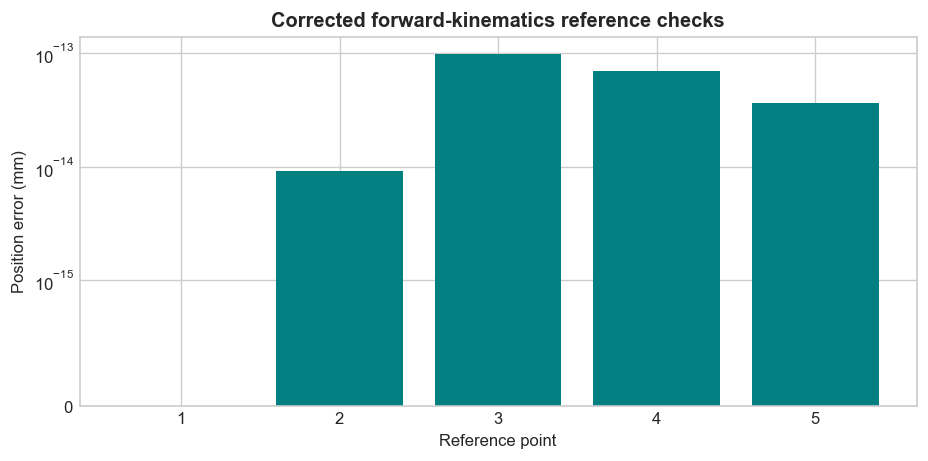

In [5]:
reference_results = []
for case in REFERENCE_CASES:
    calculated = forward_kinematics(*case.joints)
    error = np.linalg.norm(calculated - np.asarray(case.expected_position))
    reference_results.append([case.number, *case.joints, *calculated, error])
    print(f'Point {case.number}: calculated={np.round(calculated, 6)}, expected={case.expected_position}, error={error:.3e} mm')

fig, ax = plt.subplots(figsize=(9, 4))
errors = [row[-1] for row in reference_results]
ax.bar(range(1, 6), errors, color='teal')
ax.set_yscale('symlog', linthresh=1e-15)
ax.set_xlabel('Reference point'); ax.set_ylabel('Position error (mm)')
ax.set_title('Corrected forward-kinematics reference checks', fontweight='bold')
ax.set_xticks(range(1, 6))
plt.show()

### Result and interpretation
All five corrected cases agree to floating-point precision. The tiny nonzero values visible on a logarithmic scale are numerical round-off, not physical error.

## 6. Inverse kinematics and limitations

### Theory and purpose
Position alone supplies three constraints for six joint variables, so a unique general 6-DOF configuration cannot be recovered. For this demonstration the wrist posture is explicitly fixed at $\theta_2=0^\circ$, $\theta_3=90^\circ$. The solver then computes $\theta_1,l_1,l_2$ exactly; $\theta_4$ is free and may be used as an illustrative spin.

### Mathematical logic
For a selected $\theta_2,\theta_3$, define
$$B=150\cos\theta_2\sin\theta_3,\quad A=\sqrt{x^2+y^2-B^2}.$$
Then $l_2=A-150(1+\cos\theta_3)$ and $l_1=z-800-150\sin\theta_2\sin\theta_3$. The base angle follows from the corrected X-Y convention. Unreachable targets raise an error; they are not silently clamped.

### Geometric decomposition
The project report separates the positioning chain from the wrist at the common point $P_4$. This is the geometric motivation for treating position and orientation as distinct subproblems.

![Position and wrist decomposition from the project report](assets/report_ik_decomposition.png)

For the supported trajectory, the notebook solves only the position task. The wrist posture is selected explicitly, so the derivation remains transparent and does not pretend to be a general six-degree-of-freedom pose solver.

In [6]:
start_position = np.array([-150.0, 150.0, 1050.0])
end_position = np.array([0.0, 400.0, 1200.0])
for label, target in [('start', start_position), ('end', end_position)]:
    joints = inverse_position(target, theta2=0.0, theta3=90.0, theta4=0.0)
    achieved = forward_kinematics(*joints)
    print(f'{label:5s}: joints={np.round(joints, 4)}')
    print(f'       target={target}, FK(joints)={np.round(achieved, 6)}, error={np.linalg.norm(achieved-target):.3e} mm')

start: joints=[  0. 250.   0.   0.  90.   0.]
       target=[-150.  150. 1050.], FK(joints)=[-150.  150. 1050.], error=0.000e+00 mm
end  : joints=[-22.0243 400.     220.8099   0.      90.       0.    ]
       target=[   0.  400. 1200.], FK(joints)=[   0.  400. 1200.], error=0.000e+00 mm


### Result and interpretation
The two demonstration endpoints are reached exactly under the stated posture. These configurations are valid position solutions, but they do not claim to reproduce an arbitrary requested end-effector orientation.

## 7. Workspace analysis

### Theory and purpose
Workspace sampling evaluates the forward model throughout the declared joint ranges. It shows overall reach and symmetry, not collision-free or dynamically feasible motion.

### Logic and code
A moderate grid is used so the notebook remains quick to run while including the full declared angular limits.

### Geometric range from the original design
The original design drawings show the two limiting prismatic configurations. They provide an immediate physical interpretation of the dimensions used by the workspace sampler.

| Maximum extension | Minimum extension |
|---|---|
| ![Maximum robot dimensions from the project report](assets/report_maximum_dimensions.png) | ![Minimum robot dimensions from the project report](assets/report_minimum_dimensions.png) |

The base height is 800 mm and each prismatic joint ranges from 0 to 500 mm. The workspace plot below is calculated from the corrected analytical equations rather than estimated from these drawings.

Sampled 30,625 configurations
Sampled radial range: 68.87 to 800.00 mm
Sampled height range: 670.10 to 1429.90 mm


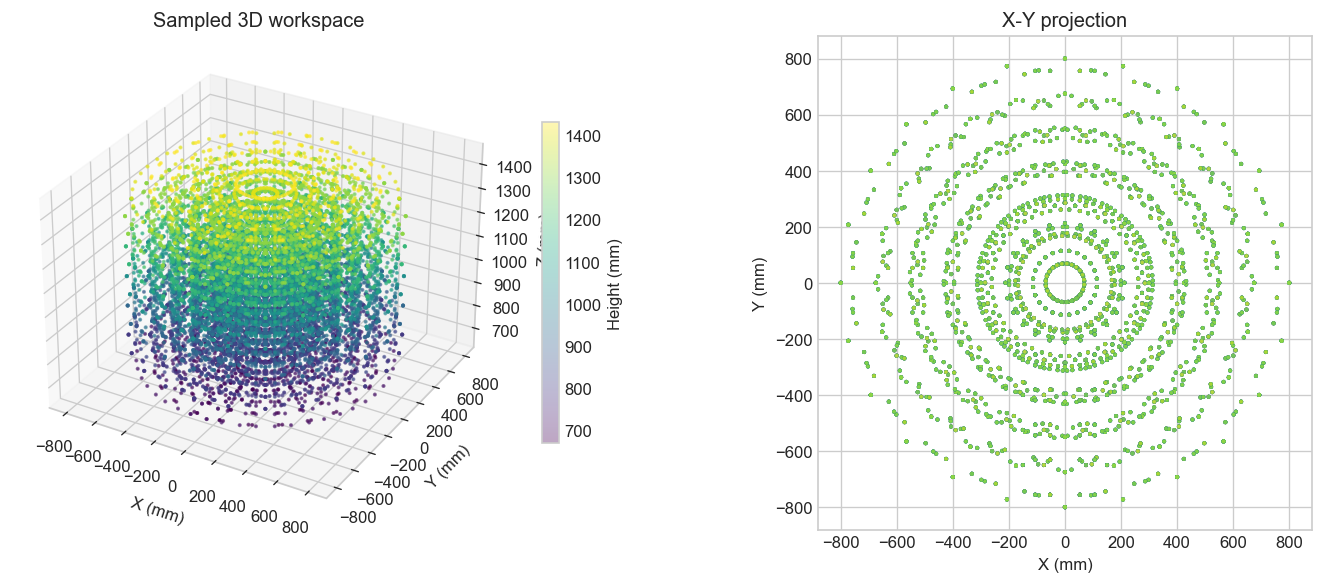

In [7]:
workspace = sample_workspace(theta1_samples=25, l1_samples=5, l2_samples=5, theta2_samples=7, theta3_samples=7)
radial = np.linalg.norm(workspace[:, :2], axis=1)
print(f'Sampled {len(workspace):,} configurations')
print(f'Sampled radial range: {radial.min():.2f} to {radial.max():.2f} mm')
print(f'Sampled height range: {workspace[:,2].min():.2f} to {workspace[:,2].max():.2f} mm')

fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(121, projection='3d')
points = ax1.scatter(workspace[:,0], workspace[:,1], workspace[:,2], c=workspace[:,2], s=2, alpha=0.35, cmap='viridis')
ax1.set(xlabel='X (mm)', ylabel='Y (mm)', zlabel='Z (mm)', title='Sampled 3D workspace')
fig.colorbar(points, ax=ax1, shrink=0.65, label='Height (mm)')
ax2 = fig.add_subplot(122)
ax2.scatter(workspace[:,0], workspace[:,1], c=workspace[:,2], s=2, alpha=0.35, cmap='viridis')
ax2.set_aspect('equal'); ax2.set(xlabel='X (mm)', ylabel='Y (mm)', title='X-Y projection')
plt.tight_layout(); plt.show()

### Result and interpretation
The X-Y projection is rotationally symmetric about Z, as expected from the unrestricted base rotation. Sampling density affects visual smoothness; these points are a numerical illustration rather than a formal boundary calculation.

## 8. Cartesian trajectory generation

### Theory and purpose
The end effector follows a straight Cartesian segment using a trapezoidal scalar speed profile: 10 seconds acceleration, 10 seconds constant speed, and 10 seconds deceleration.

### Logic
The scalar progress $s(t)$ interpolates $p(t)=p_s+s(t)(p_g-p_s)$. A zero-distance request returns a stationary trajectory instead of dividing by zero.

Samples: 751; path length: 327.872 mm
Maximum commanded speed: 16.394 mm/s


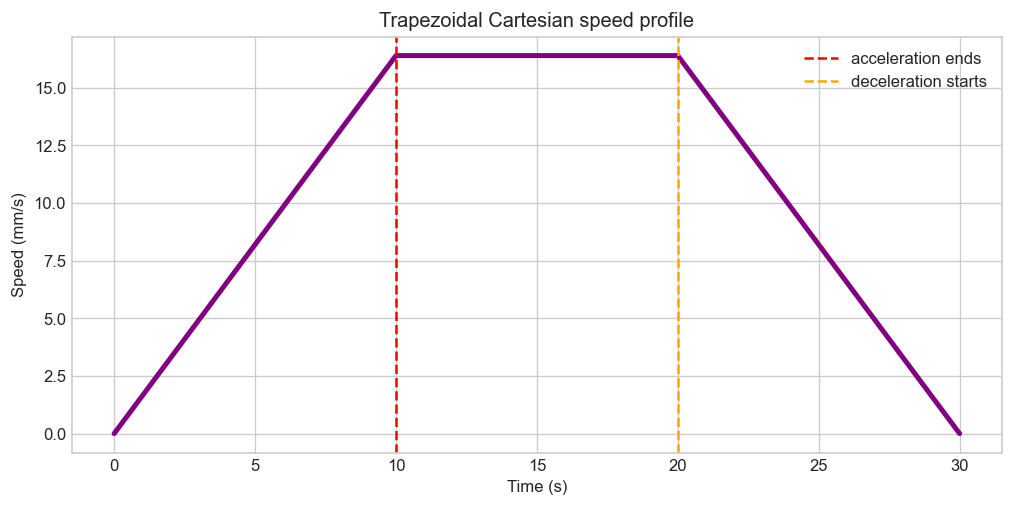

In [8]:
trajectory = plan_cartesian_trajectory(start_position, end_position)
time = trajectory['time']
print(f'Samples: {time.size}; path length: {np.linalg.norm(end_position-start_position):.3f} mm')
print(f'Maximum commanded speed: {trajectory["velocities"].max():.3f} mm/s')
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(time, trajectory['velocities'], color='purple', linewidth=3)
ax.axvline(10, color='red', linestyle='--', label='acceleration ends')
ax.axvline(20, color='orange', linestyle='--', label='deceleration starts')
ax.set(xlabel='Time (s)', ylabel='Speed (mm/s)', title='Trapezoidal Cartesian speed profile')
ax.legend(); plt.show()

### Result and interpretation
The profile reaches about 16.39 mm/s and returns continuously to zero at 30 seconds. Its acceleration changes instantaneously at phase boundaries, so it is velocity-continuous but not jerk-limited.

## 9. Commanded versus achieved trajectory

### Theory and purpose
A credible trajectory demonstration must distinguish the commanded Cartesian samples from the positions actually obtained after IK and FK.

### Logic
For every sample, the notebook solves position IK and then applies forward kinematics. The Euclidean residual is $e(t)=\lVert p_{FK}(t)-p_{cmd}(t)\rVert_2$.

Maximum position error: 1.137e-13 mm
Mean position error:    2.311e-14 mm


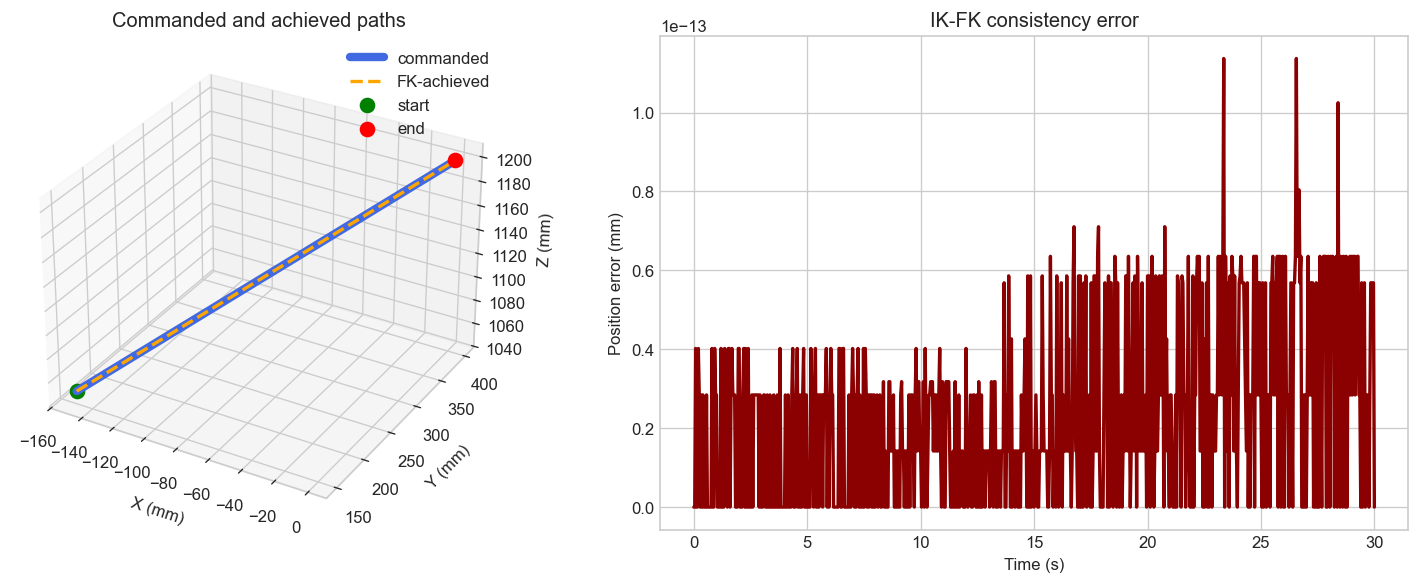

In [9]:
commanded = trajectory['commanded_positions']
achieved = trajectory['achieved_positions']
position_error = trajectory['position_error']
print(f'Maximum position error: {position_error.max():.3e} mm')
print(f'Mean position error:    {position_error.mean():.3e} mm')
fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(commanded[0], commanded[1], commanded[2], color='royalblue', linewidth=5, label='commanded')
ax1.plot(achieved[0], achieved[1], achieved[2], color='orange', linestyle='--', linewidth=2, label='FK-achieved')
ax1.scatter(*commanded[:,0], c='green', s=70, label='start')
ax1.scatter(*commanded[:,-1], c='red', s=70, label='end')
ax1.set(xlabel='X (mm)', ylabel='Y (mm)', zlabel='Z (mm)', title='Commanded and achieved paths')
ax1.legend()
ax2 = fig.add_subplot(122)
ax2.plot(time, position_error, color='darkred', linewidth=2)
ax2.set(xlabel='Time (s)', ylabel='Position error (mm)', title='IK-FK consistency error')
plt.tight_layout(); plt.show()

### Result and interpretation
The two paths overlap. The remaining residual is at floating-point scale, demonstrating that the limited position IK is genuinely consistent with the analytical forward model for this example.

## 10. Joint motion

### Theory and purpose
Joint histories show how the selected position solution realizes the Cartesian line. The posture constraint keeps $\theta_2$ and $\theta_3$ fixed; $\theta_4$ performs an illustrative 0-180° spin that does not alter position.

### Code and logic
Rotational and prismatic variables are plotted separately because their units differ.

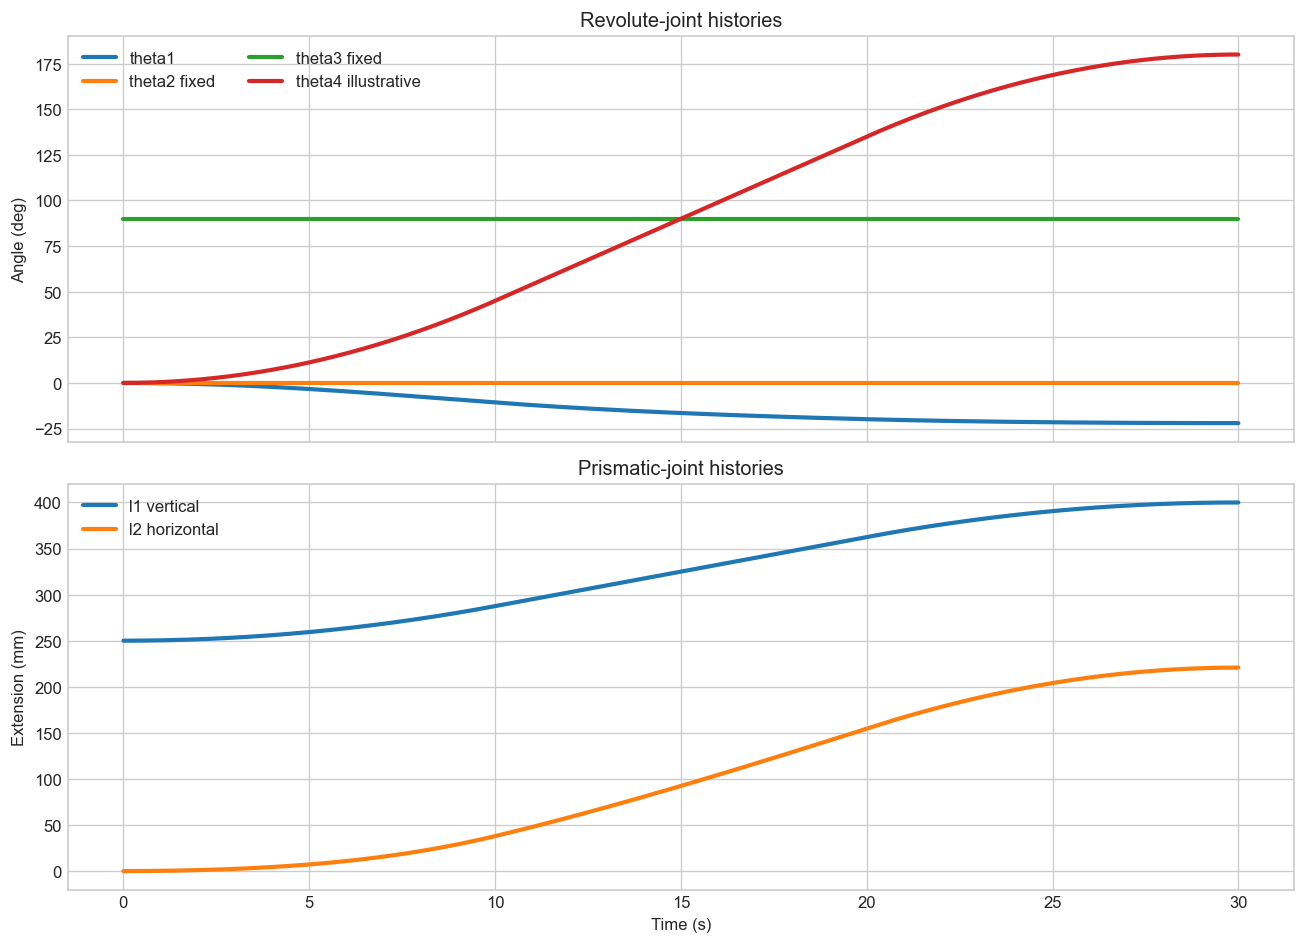

In [10]:
joint_history = trajectory['joint_configs'].T
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
for index, label in [(0,'theta1'), (3,'theta2 fixed'), (4,'theta3 fixed'), (5,'theta4 illustrative')]:
    ax1.plot(time, joint_history[index], linewidth=2.5, label=label)
ax1.set_ylabel('Angle (deg)'); ax1.set_title('Revolute-joint histories'); ax1.legend(ncol=2)
ax2.plot(time, joint_history[1], linewidth=2.5, label='l1 vertical')
ax2.plot(time, joint_history[2], linewidth=2.5, label='l2 horizontal')
ax2.set(xlabel='Time (s)', ylabel='Extension (mm)', title='Prismatic-joint histories'); ax2.legend()
plt.tight_layout(); plt.show()

### Result and interpretation
All displayed joint values remain inside the report limits. The fixed wrist posture is a deliberate simplification and should not be interpreted as general orientation tracking.

## 11. Velocity analysis

### Theory and purpose
The analytical scalar speed can be checked using finite differences of the commanded Cartesian samples. Component velocities show how the straight-line direction distributes motion across X, Y, and Z.

### Logic
A forward difference is used to mirror the original academic analysis. The final numerical value is set to zero because no later sample exists.

Max analytical/numerical speed difference: 0.0328 mm/s


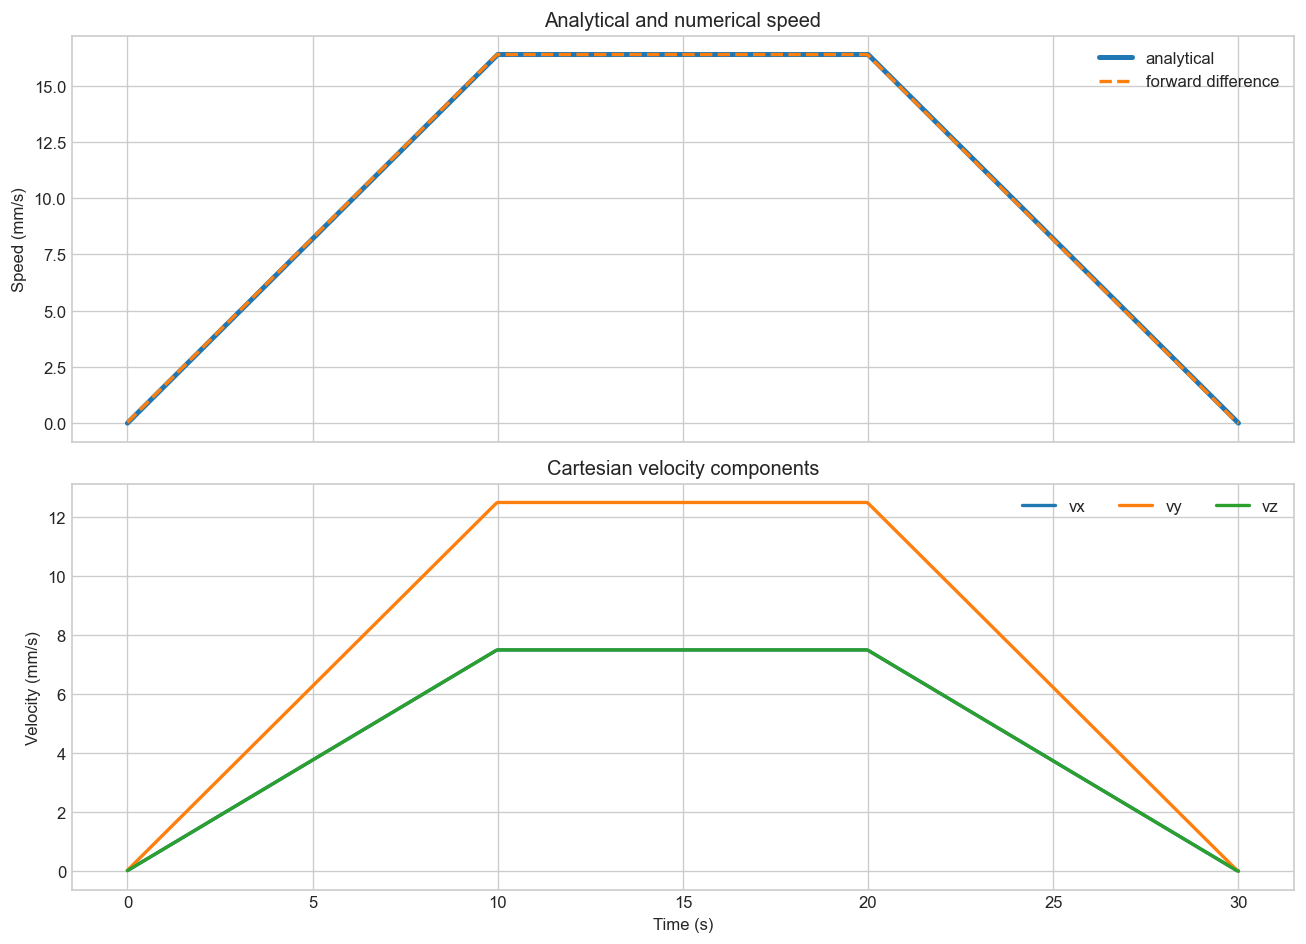

In [11]:
dt = time[1] - time[0]
velocity_components = np.zeros_like(commanded)
velocity_components[:, :-1] = np.diff(commanded, axis=1) / dt
numerical_speed = np.linalg.norm(velocity_components, axis=0)
speed_error = np.abs(numerical_speed - trajectory['velocities'])
print(f'Max analytical/numerical speed difference: {speed_error.max():.4f} mm/s')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
ax1.plot(time, trajectory['velocities'], linewidth=3, label='analytical')
ax1.plot(time, numerical_speed, '--', linewidth=2, label='forward difference')
ax1.set(ylabel='Speed (mm/s)', title='Analytical and numerical speed'); ax1.legend()
for values, label in zip(velocity_components, ['vx','vy','vz']):
    ax2.plot(time, values, linewidth=2, label=label)
ax2.set(xlabel='Time (s)', ylabel='Velocity (mm/s)', title='Cartesian velocity components'); ax2.legend(ncol=3)
plt.tight_layout(); plt.show()

### Result and interpretation
The small difference is the expected first-order discretization error. Component ratios remain constant because the commanded Cartesian path is a straight line.

## 12. Static load analysis

### Theory and purpose
The report includes a simplified static calculation for a 1 kg payload. It considers gravity and a 0.15 m tool offset; it is not a complete dynamic or structural model.

### Logic
$F_{l1}=mg$, $T_{\theta2}=mgL\cos\theta_2\sin\theta_3$, and $T_{\theta3}=mgL\sin\theta_2\cos\theta_3$.

### Physical loading model
The original project diagram below defines the simplified load case: a payload at the gripper is acted on by gravity, and the robot joints must provide the corresponding reactions.

![Payload and gravity model from the project report](assets/report_static_load_diagram.png)

The numerical analysis in this notebook isolates the payload contribution. Link self-weight, inertia, friction, and dynamic acceleration loads are deliberately excluded and are discussed as limitations.

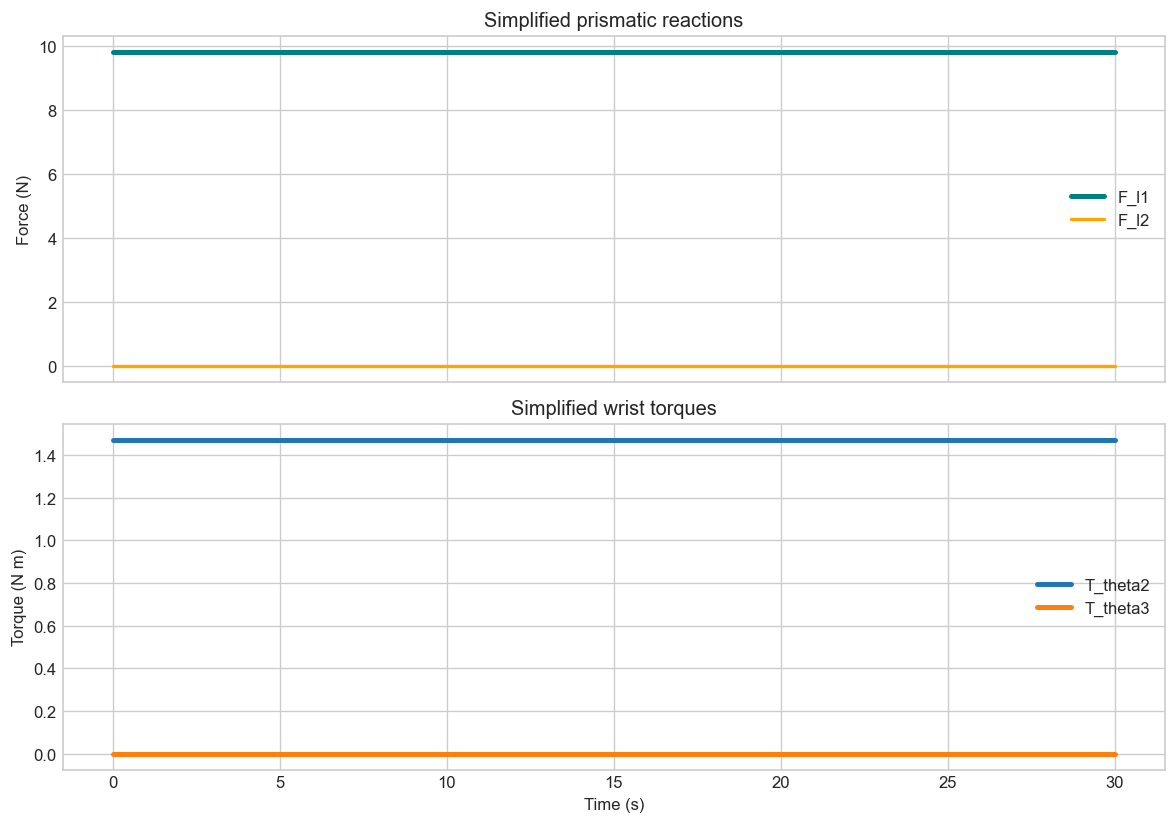

In [12]:
reactions = static_payload_reactions(trajectory['joint_configs'], mass_kg=1.0)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax1.plot(time, reactions[:,1], linewidth=3, color='teal', label='F_l1')
ax1.plot(time, reactions[:,2], linewidth=2, color='orange', label='F_l2')
ax1.set(ylabel='Force (N)', title='Simplified prismatic reactions'); ax1.legend()
ax2.plot(time, reactions[:,3], linewidth=3, label='T_theta2')
ax2.plot(time, reactions[:,4], linewidth=3, label='T_theta3')
ax2.set(xlabel='Time (s)', ylabel='Torque (N m)', title='Simplified wrist torques'); ax2.legend()
plt.tight_layout(); plt.show()

### Result and interpretation
For the fixed $\theta_2=0^\circ$, $\theta_3=90^\circ$ posture, the vertical prismatic joint carries 9.81 N and the simplified $\theta_2$ torque is maximal and constant. Inertia, link masses, friction, and actuator dynamics are intentionally omitted.

## 13. Analytical motion simulation

### Theory and purpose
The animation is a visual aid based on the analytical stick model. It illustrates the solved joint motion and path but is not a rigid-body simulator.

### Logic and code
A reduced set of trajectory frames is rendered to a GIF for direct display on GitHub.

In [13]:
from simulation import SCARASimulator
simulator = SCARASimulator()
animation_path = PROJECT_ROOT / 'notebooks' / 'scara_robot_animation.gif'
frame_indices = np.linspace(0, time.size - 1, 60, dtype=int)
animation_figure = plt.figure(figsize=(7, 6))
animation_axis = animation_figure.add_subplot(111, projection='3d')

def update_animation(frame_index):
    sample = frame_indices[frame_index]
    animation_axis.clear()
    frames = simulator.compute_robot_frames(*trajectory['joint_configs'][sample])
    animation_axis.plot(frames[:,0], frames[:,1], frames[:,2], 'o-', color='navy', linewidth=4, markersize=6)
    animation_axis.plot(commanded[0], commanded[1], commanded[2], '--', color='gray', linewidth=1.5, label='commanded')
    animation_axis.plot(achieved[0,:sample+1], achieved[1,:sample+1], achieved[2,:sample+1], color='crimson', linewidth=2.5, label='achieved')
    animation_axis.set(xlim=(-450,150), ylim=(-50,500), zlim=(0,1400), xlabel='X (mm)', ylabel='Y (mm)', zlabel='Z (mm)')
    animation_axis.set_title(f'Illustrative analytical stick model — t={time[sample]:.1f} s')
    animation_axis.view_init(elev=24, azim=42); animation_axis.legend(loc='upper left')

robot_animation = animation.FuncAnimation(animation_figure, update_animation, frames=len(frame_indices), interval=80)
robot_animation.save(animation_path, writer=animation.PillowWriter(fps=12), dpi=80)
plt.close(animation_figure)
print('Saved illustrative animation:', animation_path.relative_to(PROJECT_ROOT))

SCARA Robot Simulator initialized
Base height: 800.0 mm
Link offset: 150.0 mm
Saved illustrative animation: notebooks\scara_robot_animation.gif


### Analytical motion simulation

![Analytical motion simulation](scara_robot_animation.gif)

### Interpretation
The animation shows the commanded Cartesian path and the position achieved by the corrected analytical forward and inverse kinematics. It is the Python/Matplotlib motion simulation used in the project workflow.

## 14. ROS 2 and RViz implementation

### Theory and purpose
The robot kinematics and trajectory were developed and validated in Python. ROS 2 and RViz were used to represent the robot structure and provide a robotics-oriented visualization of the implementation.

Together, the project forms one coherent workflow:

**analytical modelling and trajectory planning in Python → animated motion demonstration → robot visualization and implementation in ROS 2 and RViz**

The ROS workspace preserves the robot model used during the project. It expresses dimensions in metres and revolute coordinates in radians, while the analytical Python work uses millimetres and degrees.

### Relevant implementation
`robot_arm.urdf.xacro` assembles the model from two files: `common_properties.xacro` contains dimensions and inertia helpers, while `mobile_base_fixed.xacro` defines the links, joints, transmissions, colors, collisions, and gripper. The two fixed wrist connectors, `joint5` and `joint7`, position successive wrist links without adding actuated degrees of freedom.

The table below maps the six analytical variables to their functional counterparts in the original ROS model. It documents the project structure without asserting exact numerical equivalence between the two representations.

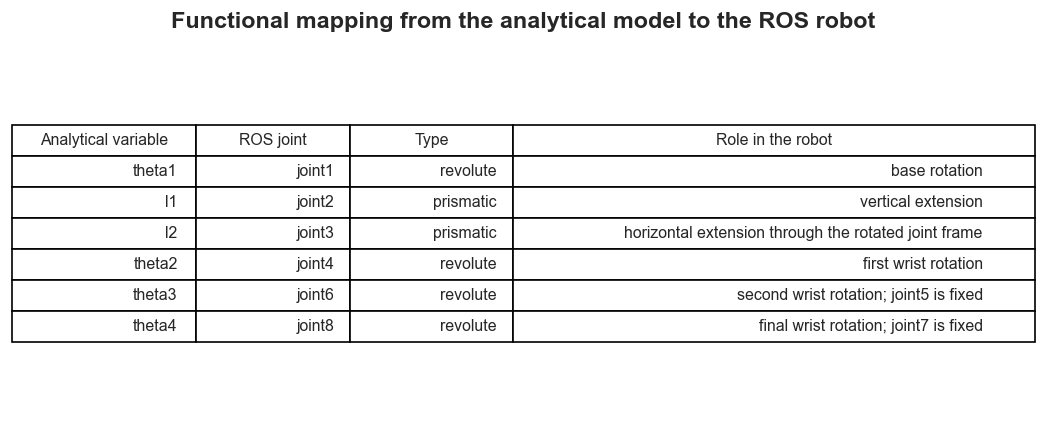

In [14]:
ros_mapping = [
    ['theta1', 'joint1', 'revolute', 'base rotation'],
    ['l1', 'joint2', 'prismatic', 'vertical extension'],
    ['l2', 'joint3', 'prismatic', 'horizontal extension through the rotated joint frame'],
    ['theta2', 'joint4', 'revolute', 'first wrist rotation'],
    ['theta3', 'joint6', 'revolute', 'second wrist rotation; joint5 is fixed'],
    ['theta4', 'joint8', 'revolute', 'final wrist rotation; joint7 is fixed'],
]
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axis('off')
table = ax.table(
    cellText=ros_mapping,
    colLabels=['Analytical variable', 'ROS joint', 'Type', 'Role in the robot'],
    colWidths=[0.18, 0.15, 0.16, 0.51],
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 1.55)
ax.set_title('Functional mapping from the analytical model to the ROS robot', fontsize=14, fontweight='bold', pad=18)
plt.show()

### Visual result: ROS robot visualization
The following authentic RViz capture from the project final report shows the Xacro robot structure, including the vertical column, translating links, articulated wrist, and gripper.

![ROS robot visualization in RViz](assets/report_rviz_figure.png)

### Professional interpretation
The analytical animation demonstrates the planned motion and its kinematic result, while RViz presents the robot as a connected link-and-joint model in a standard robotics visualization environment. These two views communicate complementary parts of the same project: quantitative analysis in Python and robot implementation in ROS 2.

### Relevant launch commands
From a ROS 2 environment, build the workspace and launch the existing model with:

```bash
cd final_ws
colcon build --symlink-install
source install/setup.bash
ros2 launch robot_arm_description display.launch.xml
```

The project also includes its Gazebo launch entry point:

```bash
ros2 launch robot_arm_bringup robot_arm_gazebo.launch.xml
```

**Technical note:** GitHub displays the recorded simulation output; running the interactive RViz/Gazebo environment requires a local ROS 2 installation.

## 15. Conclusions and possible future improvements

### Result
This walkthrough establishes a consistent analytical convention, validates all five corrected report cases, uses an explicit position-IK posture for the example trajectory, and distinguishes commanded from forward-kinematics-achieved motion. The executed plots and analytical animation present the numerical workflow, while the ROS 2 Xacro model and authentic RViz result present the robot implementation.

### Interpretation and future work
The project now reads as a coherent academic robotics demonstration from mathematical modelling through visualization. Future work could add general rotation-matrix pose IK, branch and singularity handling, jerk-limited trajectories, collision checking, and a newly recorded ROS/Gazebo run on a compatible ROS 2 system.